# 02. Weighted CNN Baseline for Melanoma Classification

**Objective**  
Extend the plain CNN baseline by introducing class weighting in `BCEWithLogitsLoss` so that melanoma mistakes are penalized more heavily during training. This notebook tests whether a weighted loss improves minority-class detection without changing the underlying CNN architecture.

**Model Architecture**

| Stage | Layers |
| --- | --- |
| Input | RGB dermoscopic image |
| Block 1 | `Conv2d -> ReLU -> MaxPool2d` |
| Block 2 | `Conv2d -> ReLU -> MaxPool2d` |
| Block 3 | `Conv2d -> ReLU -> MaxPool2d` |
| Classifier | `Flatten -> Linear(128 x 28 x 28, 256) -> ReLU -> Dropout -> Linear(256, 1)` |

**Hypothesis**  
Compared with the unweighted baseline, adding `pos_weight` should increase melanoma recall and improve recall-focused metrics such as F2 and balanced accuracy. The trade-off is that precision and overall accuracy may decrease because the model becomes more willing to predict melanoma.


### 1. Setup and Imports

This section loads the project modules, trainer utilities, and shared evaluation helpers, then selects the available compute device (`CUDA`, `MPS`, or `CPU`).


In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.cnn_baseline import SimpleCNN
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


### 2. Data Split and Weighted-Loss Configuration

The dataset is loaded using the predefined train, validation, and test CSV splits.  
This experiment keeps the same `SimpleCNN` architecture as Notebook 01, but changes the loss from unweighted BCE to weighted BCE:

- `SimpleCNN` as the feature extractor and classifier
- `BCEWithLogitsLoss(pos_weight=...)` to penalize missed melanoma more strongly
- `Adam` with learning rate `1e-3`
- Batch size `32` and image size `224 x 224`

The positive-class weight is computed as:

`pos_weight = number_of_nevus / number_of_melanoma`

This makes melanoma errors contribute more to the training loss because melanoma is the minority class.


In [2]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / "data_new/splits/train.csv"),
    val_csv=str(ROOT / "data_new/splits/val.csv"),
    test_csv=str(ROOT / "data_new/splits/test.csv"),
    image_dir=str(ROOT / "data_new/images/train"),
    test_image_dir=str(ROOT / "data_new/images/test"),
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv(ROOT / "data_new/splits/train.csv")

num_melanoma = (train_df["label"] == 1).sum()
num_nevus = (train_df["label"] == 0).sum()

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32, device=device)

# raw_pos_weight = num_nevus / num_melanoma
# soft_pos_weight = min(raw_pos_weight, 4.0)   # or 5.0
# pos_weight = torch.tensor([soft_pos_weight], dtype=torch.float32, device=device)

print(f"Melanoma samples: {num_melanoma}")
print(f"Nevus samples: {num_nevus}")
print(f"pos_weight: {pos_weight.item():.4f}")


model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


Melanoma samples: 877
Nevus samples: 7114
pos_weight: 8.1117


### 3. Train the Weighted Baseline Model

The model is trained for `20` epochs using the same CNN as Notebook 01, but with weighted BCE loss. Training and validation metrics are stored as lists of dictionaries so they can be passed directly into the shared plotting function later. The checkpoint with the highest validation AUC is saved as the best model.

In [3]:
num_epochs = 20

best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")


    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/cnn_baseline_weighted.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')


Epoch [1/20]
  Train | Loss: 1.0917, Bal Acc: 0.6791, Recall: 0.7993, F2: 0.4771, AUC: 0.7407
  Val   | Loss: 1.0586, Bal Acc: 0.6816, Recall: 0.9576, F2: 0.5060, AUC: 0.7789
  -> Saved best model (val AUC: 0.7789)


Epoch [2/20]
  Train | Loss: 1.0392, Bal Acc: 0.6973, Recall: 0.7925, F2: 0.4940, AUC: 0.7667
  Val   | Loss: 0.9807, Bal Acc: 0.7315, Recall: 0.8602, F2: 0.5466, AUC: 0.8098
  -> Saved best model (val AUC: 0.8098)


Epoch [3/20]
  Train | Loss: 0.9655, Bal Acc: 0.7376, Recall: 0.8461, F2: 0.5386, AUC: 0.7981
  Val   | Loss: 1.0054, Bal Acc: 0.7285, Recall: 0.7373, F2: 0.5374, AUC: 0.8037


Epoch [4/20]
  Train | Loss: 0.9296, Bal Acc: 0.7379, Recall: 0.8301, F2: 0.5387, AUC: 0.8053
  Val   | Loss: 0.9313, Bal Acc: 0.7159, Recall: 0.9407, F2: 0.5347, AUC: 0.8341
  -> Saved best model (val AUC: 0.8341)


Epoch [5/20]
  Train | Loss: 0.8788, Bal Acc: 0.7618, Recall: 0.8734, F2: 0.5664, AUC: 0.8324
  Val   | Loss: 0.8398, Bal Acc: 0.7703, Recall: 0.8644, F2: 0.5906, AUC: 0.8513
  -> Saved best model (val AUC: 0.8513)


...

Epoch [16/20]
  Train | Loss: 1.0157, Bal Acc: 0.7620, Recall: 0.8084, F2: 0.5681, AUC: 0.8454
  Val   | Loss: 0.8814, Bal Acc: 0.7643, Recall: 0.9195, F2: 0.5833, AUC: 0.8557


Epoch [17/20]
  Train | Loss: 0.7867, Bal Acc: 0.7973, Recall: 0.8620, F2: 0.6130, AUC: 0.8731
  Val   | Loss: 0.8995, Bal Acc: 0.7529, Recall: 0.9280, F2: 0.5709, AUC: 0.8559


Epoch [18/20]
  Train | Loss: 0.7530, Bal Acc: 0.8039, Recall: 0.8643, F2: 0.6222, AUC: 0.8846
  Val   | Loss: 0.8560, Bal Acc: 0.7698, Recall: 0.7924, F2: 0.5907, AUC: 0.8581


Epoch [19/20]
  Train | Loss: 0.7387, Bal Acc: 0.8087, Recall: 0.8757, F2: 0.6282, AUC: 0.8864
  Val   | Loss: 0.8673, Bal Acc: 0.7585, Recall: 0.8263, F2: 0.5762, AUC: 0.8475


Epoch [20/20]
  Train | Loss: 0.7233, Bal Acc: 0.8149, Recall: 0.8757, F2: 0.6373, AUC: 0.8931
  Val   | Loss: 0.8755, Bal Acc: 0.7730, Recall: 0.8475, F2: 0.5942, AUC: 0.8596
  -> Saved best model (val AUC: 0.8596)


### 4. Plot Training Curves

This notebook uses the shared evaluation utility to render the standard 2 × 2 dashboard: Loss, Balanced Accuracy, Recall, and F2. This keeps the weighted experiment directly comparable with Notebook 01.


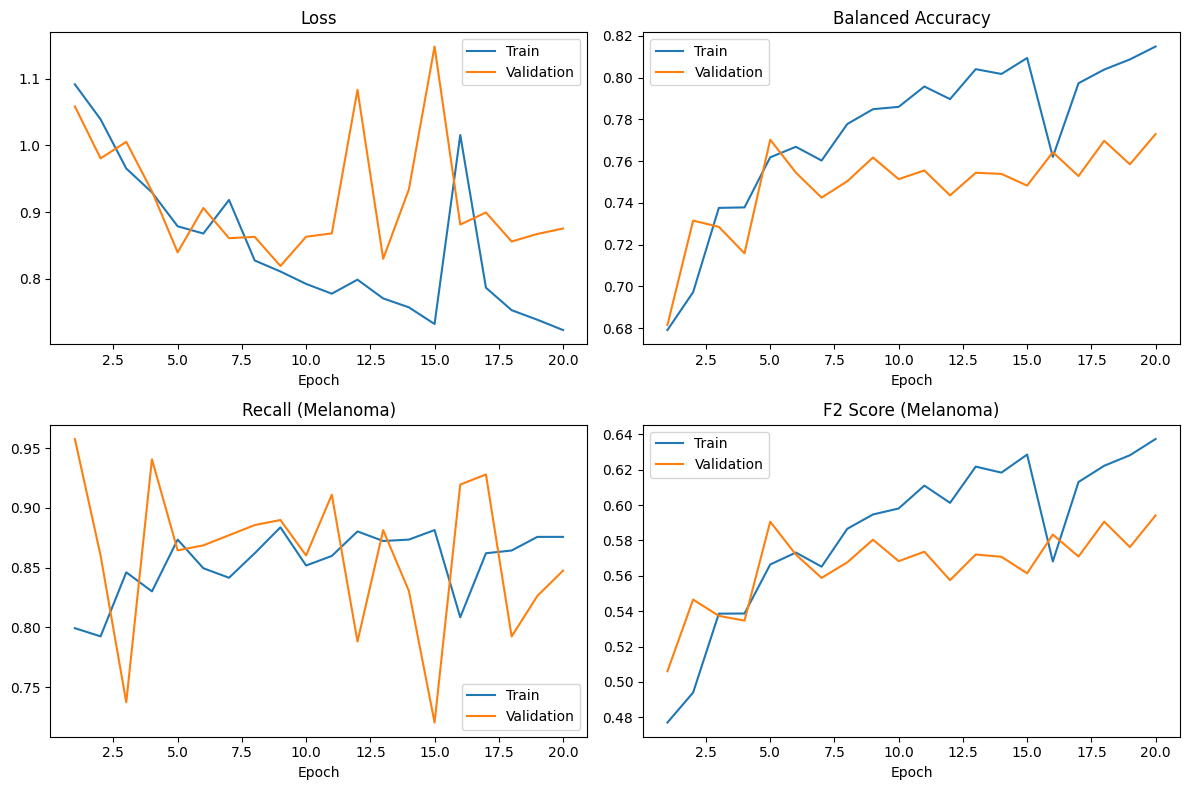

In [4]:
plot_training_curves(train_history, val_history)

### 5. Tune the Classification Threshold on the Validation Set


In [5]:
model.load_state_dict(torch.load(ROOT / 'models/cnn_baseline_weighted.pth', map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

print(f"Best validation threshold: {best_threshold:.2f}")
print(f"Best validation F2: {best_f2:.4f}")

Best threshold: 0.49 | Val F2: 0.5945
Best validation threshold: 0.49
Best validation F2: 0.5945


### 6. Evaluate on the Test Set

The final test evaluation is performed using:
- the model checkpoint selected by highest validation AUC
- the decision threshold selected on the validation set by maximizing F2-score


Threshold:          0.49
AUC-ROC:            0.8471
Balanced Accuracy:  0.7562
F2 Score:           0.5670

              precision    recall  f1-score   support

Non-Melanoma     0.9750    0.6410    0.7735      1340
    Melanoma     0.2365    0.8713    0.3720       171

    accuracy                         0.6671      1511
   macro avg     0.6058    0.7562    0.5728      1511
weighted avg     0.8914    0.6671    0.7281      1511



/Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


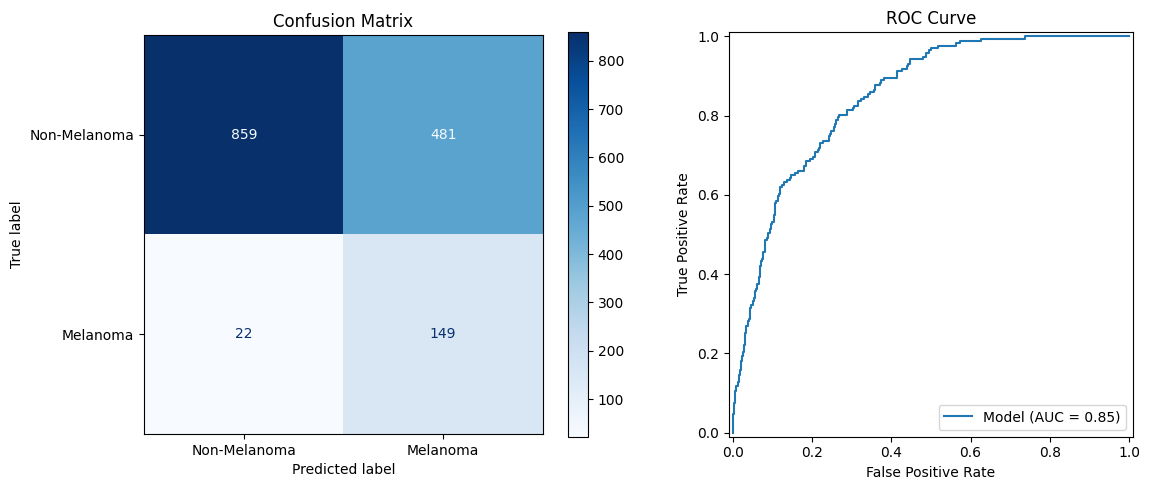

In [6]:
evaluate_model(model, test_loader, device, threshold=best_threshold)

### Summary of Results and Next Steps

**Current Results (Weighted CNN Baseline)**
- AUC ≈ 0.847, best threshold = 0.49 → model has moderate class separation
- Melanoma recall ≈ 0.871 → strongly favors sensitivity and catches most positive cases
- Melanoma precision ≈ 0.237 → many false positives remain
- Balanced Accuracy ≈ 0.756, F2 ≈ 0.567 → recall improved, but overall precision-recall balance is still limited
- Conclusion: class weighting pushes the model toward a more recall-heavy screening operating point, but feature representation still needs improvement

**Next Step: Add Batch Normalization**
- Insert `BatchNorm2d` after each convolution layer
- Keep all other components the same (loss, weighting, threshold tuning)

**Why BatchNorm**
- Stabilizes training and improves convergence
- Helps the model learn better feature representations
- Can improve generalization and reduce overfitting
- Allows fair comparison since only architecture changes